**Politechnika Białostocka**

**Wydział Informatyki**

**Pracownia specjalistyczna**

**Sztuczna Inteligencja**

**Projekt analiza danych**

Autorzy:


*   Patryk Romanowicz
*   Miłosz Michalski
*   Tomasz Chodorowski
*   Michał Chomontowski

Data wykonania: 11.06.2026

**Ładowanie zbioru danych**

In [ ]:
# Dołączenie bibliotek
import kagglehub
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import psutil
import platform
import subprocess
import warnings
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
from sklearn.exceptions import ConvergenceWarning

# Pobranie danych
path = kagglehub.dataset_download("sherrytp/airline-delay-analysis")
target_file = "2019.csv"
full_path = ""
for root, dirs, files in os.walk(path):
    if target_file in files:
        full_path = os.path.join(root, target_file)
        break

# Sprawdzenie czy udało się poprawnie załadować dane
if full_path:
    print("\nSUKCES")
    print(f"Znaleziono plik: {full_path}")
    # Załadowanie 1,5mln wierszy z datasetu
    df = pd.read_csv(full_path, nrows=1500000, low_memory=False)
    print(f"Liczba wierszy: {len(df)}")
    print(f"Liczba kolumn: {df.shape[1]}")
else:
    print("\nBŁĄD")
    print(f"Nie znaleziono pliku {target_file}")

# Dane
df.head()

Using Colab cache for faster access to the 'airline-delay-analysis' dataset.

SUKCES
Znaleziono plik: /kaggle/input/airline-delay-analysis/airline delay analysis/2019.csv
Liczba wierszy: 1500000
Liczba kolumn: 21


,FL_DATE,OP_UNIQUE_CARRIER,OP_CARRIER_FL_NUM,ORIGIN,DEST,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,...,ARR_TIME,ARR_DELAY,AIR_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,Unnamed: 20
0,2019-01-01,9E,3280,GNV,ATL,601.0,1.0,22.0,623.0,714.0,...,722.0,-1.0,51.0,300.0,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-01-01,9E,3281,MSP,CVG,1359.0,-5.0,15.0,1414.0,1629.0,...,1633.0,-36.0,75.0,596.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-01-01,9E,3282,DTW,CVG,1215.0,-5.0,18.0,1233.0,1323.0,...,1329.0,-16.0,50.0,229.0,NaN,NaN,NaN,NaN,NaN,NaN
3,2019-01-01,9E,3283,TLH,ATL,1521.0,-6.0,14.0,1535.0,1618.0,...,1625.0,-14.0,43.0,223.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2019-01-01,9E,3284,ATL,FSM,1847.0,-15.0,18.0,1905.0,1935.0,...,1940.0,-25.0,90.0,579.0,NaN,NaN,NaN,NaN,NaN,NaN


**Informacje o środowisku wykonawczym**

In [ ]:
# Informacje o środowisku wykonawczym
print("="*22 + " Informacje systemowe " + "="*22)
print(f"System operacyjny     : {platform.linux_distribution()[0] if hasattr(platform, 'linux_distribution') else 'Ubuntu'} {platform.release()}")
print(f"Wersja jądra (Kernel) : {platform.uname().release}")
print(f"Wersja Pythona        : {platform.python_version()}")
print("-"*66)

# CPU
cpu_model = subprocess.getoutput("cat /proc/cpuinfo | grep 'model name' | head -1 | cut -d: -f2").strip()
print(f"Procesor (CPU)      : {cpu_model}")
print(f"Rdzenie CPU         : {psutil.cpu_count(logical=False)} fizycznych / {psutil.cpu_count(logical=True)} logicznych")

# RAM
ram = psutil.virtual_memory()
print(f"Pamięć RAM          : {ram.total / (1024**3):.2f} GB (Dostępne: {ram.available / (1024**3):.2f} GB)")

# Dysk
disk = psutil.disk_usage('/')
print(f"Dysk (Miejsce)      : {disk.total / (1024**3):.2f} GB (Wolne: {disk.free / (1024**3):.2f} GB)")

# GPU
try:
    gpu = subprocess.getoutput("nvidia-smi --query-gpu=gpu_name --format=csv,noheader")
    if "not found" not in gpu and "failed" not in gpu:
        print(f"Karta graficzna GPU : {gpu}")
    else:
        print("Karta graficzna GPU : Brak (aktywne tylko CPU)")
except:
    print("Karta graficzna GPU : Brak (aktywne tylko CPU)")
print("="*66)

====================== Informacje systemowe ======================
System operacyjny     : Ubuntu 6.6.122+
Wersja jądra (Kernel) : 6.6.122+
Wersja Pythona        : 3.12.13
------------------------------------------------------------------
Procesor (CPU)      : Intel(R) Xeon(R) CPU @ 2.20GHz
Rdzenie CPU         : 1 fizycznych / 2 logicznych
Pamięć RAM          : 12.67 GB (Dostępne: 10.61 GB)
Dysk (Miejsce)      : 107.72 GB (Wolne: 79.17 GB)
Karta graficzna GPU : Brak (aktywne tylko CPU)


**Przygotowanie danych**

In [ ]:
# Usuwamy zbędne kolumny
cols_to_drop = [
    'CARRIER_DELAY',
    'WEATHER_DELAY',
    'NAS_DELAY',
    'SECURITY_DELAY',
    'LATE_AIRCRAFT_DELAY',
    'Unnamed: 20'
]

df = df.drop(columns=cols_to_drop, errors='ignore')
df = df.dropna(subset=['ARR_DELAY'])

# Jeśli opóźnienie przekracza 15 minut to 1 w przeciwnym razie 0
df['IS_DELAYED'] = (df['ARR_DELAY'] > 15).astype(int)

print("Statystyki kolumny IS_DELAYED:")
print(df['IS_DELAYED'].value_counts())
print("\nRozkład procentowy:")
print(df['IS_DELAYED'].value_counts(normalize=True) * 100)

Statystyki kolumny IS_DELAYED:
IS_DELAYED
0    1165839
1     289120
Name: count, dtype: int64

Rozkład procentowy:
IS_DELAYED
0    80.12865
1    19.87135
Name: proportion, dtype: float64


**Analiza zbioru treningowego**

Źródło danych
Dane pochodzą z **datasetu Airline Delay Analysis** dostępnego na platformie Kaggle (autor: sherrytp). Wykorzystano plik 2019.csv zawierający informacje o lotach krajowych w Stanach Zjednoczonych z roku 2019. Do analizy załadowano 1 500 000 wierszy z dostępnego zbioru.

Struktura zbioru
Oryginalny dataset zawiera 21 kolumn. Po wstępnym przetworzeniu usunięto 6 zbędnych kolumn:

CARRIER_DELAY — opóźnienie z winy przewoźnika

WEATHER_DELAY — opóźnienie z powodu pogody

NAS_DELAY — opóźnienie krajowego systemu lotniczego

SECURITY_DELAY — opóźnienie z powodów bezpieczeństwa

LATE_AIRCRAFT_DELAY — opóźnienie spowodowane spóźnieniem samolotu

Unnamed: 20 — pusta kolumna artefaktowa

Po czyszczeniu **(usunięcie wierszy z brakiem wartości w kolumnie ARR_DELAY)** zbiór liczy 1 454 959 wierszy i 15 kolumn roboczych.

Zmienna docelowa — IS_DELAYED

Na podstawie kolumny ARR_DELAY **(rzeczywiste opóźnienie przylotu w minutach)** stworzono binarną zmienną docelową według reguły:

Lot jest opóźniony (IS_DELAYED = 1) jeśli opóźnienie przekroczyło 15 minut, w przeciwnym razie oznaczony jest jako punktualny (IS_DELAYED = 0).

------------------------------------------------------------------------------------

Rozkład klas w zbiorze:

**0 — Punktualny**

Liczba lotów: 1 165 839

Udział procentowy: 80,13%

**1 — Opóźniony**

Liczba lotów: 289 120

Udział procentowy: 19,87%




Zbiór jest niezbalansowany — klasa pozytywna (opóźniony) stanowi niespełna 20% obserwacji. Z tego względu w modelach zastosowano mechanizmy wyrównujące klasy (class_weight='balanced' w drzewie decyzyjnym oraz undersampling w sieciach neuronowych).

-------------------------------------------------------------------------------


Preprocessing:

Ekstrakcja cech z daty — z kolumny FL_DATE wyodrębniono: miesiąc (MONTH), dzień tygodnia (DAY_OF_WEEK) oraz dzień miesiąca (DAY_OF_MONTH).

Kodowanie zmiennych kategorycznych — kolumny OP_UNIQUE_CARRIER, ORIGIN, DEST zakodowano numerycznie przy użyciu LabelEncoder.

Uzupełnienie braków — brakujące wartości w cechach zastąpiono zerem (fillna(0)).
Skalowanie — dla sieci neuronowych zastosowano StandardScaler (krytyczne dla poprawności działania MLP).

-------------------------------------------------------------------------------

Podział na zbiór treningowy i testowy:

Eksperymenty z drzewami decyzyjnymi używały podziału 70/30 (test_size=0.3, random_state=42). W eksperymentach z sieciami neuronowymi testowano trzy warianty podziału: 90/10, 80/20 i 70/30.


**Analiza istotności cech**

Istotność cech
DAY_OF_MONTH         0.210468
ORIGIN               0.184266
DEST                 0.154634
MONTH                0.109779
OP_UNIQUE_CARRIER    0.093172
OP_CARRIER_FL_NUM    0.088442
DISTANCE             0.080624
DAY_OF_WEEK          0.078614
dtype: float64


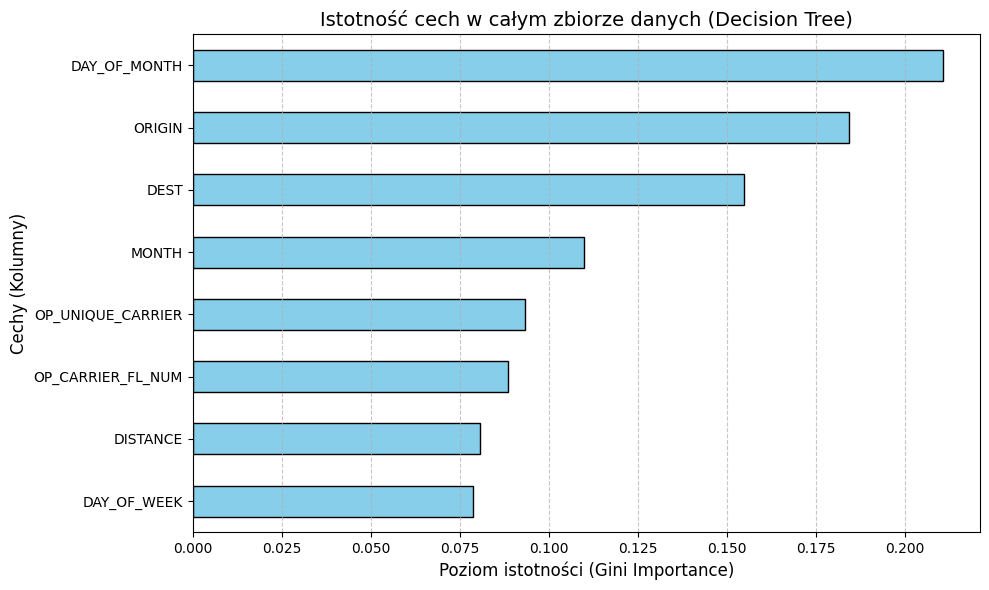

In [ ]:
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])
df['MONTH'] = df['FL_DATE'].dt.month
df['DAY_OF_WEEK'] = df['FL_DATE'].dt.dayofweek
df['DAY_OF_MONTH'] = df['FL_DATE'].dt.day

le = LabelEncoder()
categorical_cols = ['OP_UNIQUE_CARRIER', 'ORIGIN', 'DEST']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))


all_features = [
    'MONTH', 'DAY_OF_WEEK', 'DAY_OF_MONTH',
    'OP_UNIQUE_CARRIER', 'OP_CARRIER_FL_NUM',
    'ORIGIN', 'DEST', 'DISTANCE'
]

X = df[all_features].fillna(0)
y = df['IS_DELAYED']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model_global = DecisionTreeClassifier(
    max_depth=12,
    random_state=42,
    class_weight='balanced'
)
model_global.fit(X_train, y_train)

# Obliczanie istotności cech
importances = model_global.feature_importances_
feat_importances = pd.Series(importances, index=all_features).sort_values(ascending=True)

# Wyświetlenie tekstowe
print("Istotność cech")
print(feat_importances.sort_values(ascending=False))

# Generowanie wykresu słupkowego
plt.figure(figsize=(10, 6))
feat_importances.plot(kind='barh', color='skyblue', edgecolor='black')
plt.title('Istotność cech w całym zbiorze danych (Decision Tree)', fontsize=14)
plt.xlabel('Poziom istotności (Gini Importance)', fontsize=12)
plt.ylabel('Cechy (Kolumny)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Obserwacje i wnioski dt. analizy cech:**

Wykres przedstawia hierarchiczny rozkład ważności cech obliczony za pomocą algorytmu drzewa decyzyjnego (kryterium Gini Importance). Na pierwszym planie wyraźnie odznaczają się trzy cechy o najwyższym współczynniku: DAY_OF_MONTH (0.210), ORIGIN (0.184) oraz DEST (0.155).

Najważniejszym pojedynczym czynnikiem branym pod uwagę przez algorytm przy podejmowaniu decyzji jest konkretny dzień miesiąca. Kolejne dwa miejsca zajmują informacje o lokalizacji (lotnisko wylotu i przylotu). Sygnalizuje to, że w badanym zbiorze danych kombinacja momentu w czasie (dzień) oraz punktów geograficznych (lotniska) niesie w sobie najwięcej informacji i pozwala na najsilniejszą separację klas.

Środkową część rankingu zajmują cechy związane z ogólnym miesiącem (MONTH – 0.110), identyfikatorem linii lotniczej (OP_UNIQUE_CARRIER – 0.093) oraz konkretnym numerem rejsu (OP_CARRIER_FL_NUM – 0.088). Wskazuje to, że ogólna charakterystyka przewoźnika lub szeroki sezon roczny mają mniejsze znaczenie różnicujące niż precyzyjny dzień i trasa lotu.

Na samym dole zestawienia z najniższymi wartościami współczynnika istotności znalazły się cechy DISTANCE (0.081) oraz DAY_OF_WEEK (0.079). Wynika z tego, że fizyczna odległość pomiędzy lotniskami oraz konkretny dzień tygodnia wnoszą relatywnie najmniej nowej wiedzy do struktury podziałów drzewa decyzyjnego w analizowanym problemie klasyfikacji.



**Eksperymenty z 8 cechami**

In [ ]:
# Wyciszenie ostrzeżeń o małej liczbie epok
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Przygotowanie danych
features = ['DAY_OF_MONTH', 'ORIGIN', 'OP_UNIQUE_CARRIER', 'DEST', 'MONTH', 'OP_CARRIER_FL_NUM', 'DISTANCE', 'DAY_OF_WEEK']
X = df[features].fillna(0)
y = df['IS_DELAYED']

# Konfiguracja dancyh
test_sizes = [0.1, 0.2, 0.3]
hidden_layers = [(64,), (32, 16)]
activations = ['relu', 'tanh']
max_iters = [10, 50, 150]

nn_results = []
exp_cnt = 1

# Pętla generująca eksperymenty
for t_size in test_sizes:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=t_size, random_state=42)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for layer in hidden_layers:
        for activation in activations:
            for epochs in max_iters:
                print(f"Exp {exp_cnt}/36: TestSize={t_size}, Layers={layer}, Activation={activation}, MaxEpochs={epochs}")

                # Model sieci z early_stopping
                mlp = MLPClassifier(
                    hidden_layer_sizes=layer,
                    activation=activation,
                    max_iter=epochs,
                    early_stopping=True,    # Włączone wczesne zatrzymywanie
                    validation_fraction=0.1, # 10% zbioru treningowego idzie na walidację dla early stopping
                    random_state=42
                )

                mlp.fit(X_train_scaled, y_train)
                y_pred = mlp.predict(X_test_scaled)

                cm = confusion_matrix(y_test, y_pred)

                nn_results.append({
                    "Exp": exp_cnt,
                    "Test_Size": t_size,
                    "Architecture": str(layer),
                    "Activation": activation,
                    "Max_Epochs": epochs,
                    "Actual_Epochs": mlp.n_iter_, # Ile epok faktycznie wykonała sieć przed stopem
                    "Accuracy": accuracy_score(y_test, y_pred),
                    "Precision": precision_score(y_test, y_pred, zero_division=0),
                    "Recall": recall_score(y_test, y_pred, zero_division=0),
                    "TN": cm[0,0], "FP": cm[0,1],
                    "FN": cm[1,0], "TP": cm[1,1]
                })
                exp_cnt += 1

# Wyniki w tabeli
nn_results_df = pd.DataFrame(nn_results)
print("\nWyniki eksperymentów")
print(nn_results_df.to_string(index=False))

Exp 1/36: TestSize=0.1, Layers=(64,), Activation=relu, MaxEpochs=10
Exp 2/36: TestSize=0.1, Layers=(64,), Activation=relu, MaxEpochs=50
Exp 3/36: TestSize=0.1, Layers=(64,), Activation=relu, MaxEpochs=150
Exp 4/36: TestSize=0.1, Layers=(64,), Activation=tanh, MaxEpochs=10
Exp 5/36: TestSize=0.1, Layers=(64,), Activation=tanh, MaxEpochs=50
Exp 6/36: TestSize=0.1, Layers=(64,), Activation=tanh, MaxEpochs=150
Exp 7/36: TestSize=0.1, Layers=(32, 16), Activation=relu, MaxEpochs=10
Exp 8/36: TestSize=0.1, Layers=(32, 16), Activation=relu, MaxEpochs=50
Exp 9/36: TestSize=0.1, Layers=(32, 16), Activation=relu, MaxEpochs=150
Exp 10/36: TestSize=0.1, Layers=(32, 16), Activation=tanh, MaxEpochs=10
Exp 11/36: TestSize=0.1, Layers=(32, 16), Activation=tanh, MaxEpochs=50
Exp 12/36: TestSize=0.1, Layers=(32, 16), Activation=tanh, MaxEpochs=150
Exp 13/36: TestSize=0.2, Layers=(64,), Activation=relu, MaxEpochs=10
Exp 14/36: TestSize=0.2, Layers=(64,), Activation=relu, MaxEpochs=50
Exp 15/36: TestSize=0

**Obserwacje:**

Wszystkie badane modele osiągały stabilną, wysoką dokładność ogólną (Accuracy) na poziomie około 80%. Zwiększanie limitu epok (Max_Epochs) do 50 i 150 nie wpływało na końcowy rezultat – algorytm w każdym z tych przypadków automatycznie przerywał proces uczenia dokładnie po 12 epokach.

W większości prób liczba poprawnie wykrytych opóźnień (TP) wynosiła zero, co przełożyło się na zerową czułość (Recall = 0).

Jedynie konfiguracje łączące funkcję aktywacji tanh z dwuwarstwową architekturą (32, 16) generowały pojedyncze, poprawne predykcje opóźnień (maksymalnie 17 trafień na ponad 86 tysięcy przypadków w eksperymencie 34), uzyskując wskaźnik Precision na poziomie około 55–65% przy skrajnie niskim Recall (ok. 0.0002).

**Wnioski:**

Wysoki wynik ogólnej dokładności (Accuracy) był pozorny i wynikał z faktu, że każda z konfiguracji sieci neuronowej niemal bezwyjątkowo klasyfikowała wszystkie loty jako punktualne (wysokie wartości TN), co obnażyło całkowity brak zdolności modeli do rozpoznawania klasy pozytywnej.

Działanie mechanizmu Early Stopping (przerywanie pracy po 12 epokach) jednoznacznie wskazuje na brak redukcji błędu na zbiorze walidacyjnym w miarę dalszego treningu, co oznacza, że sieć bardzo szybko utknęła w minimum lokalnym klasyfikacji większościowej. Wskaźnik Recall na poziomie 0.0002 w nielicznych konfiguracjach potwierdza, że modele w obecnej formie są skrajnie niefunkcjonalne w praktycznym zastosowaniu.

**Eksperymenty z 8 cechami i undersamplingiem**

In [ ]:
# Wyciszenie ostrzeżeń o małej liczbie epok
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Przygotowanie danych
features = ['DAY_OF_MONTH', 'ORIGIN', 'OP_UNIQUE_CARRIER', 'DEST', 'MONTH', 'OP_CARRIER_FL_NUM', 'DISTANCE', 'DAY_OF_WEEK']

# Balansowanie danych (undersampling)
df_delayed = df[df['IS_DELAYED'] == 1]
df_ontime = df[df['IS_DELAYED'] == 0]

# Losujemy z klasy większościowej dokładnie tyle samo rekordów, ile jest w mniejszościowej
df_ontime_sampled = df_ontime.sample(n=len(df_delayed), random_state=42)

# Łączymy zbalansowane grupy i mieszamy kolejność wierszy
df_balanced = pd.concat([df_delayed, df_ontime_sampled]).sample(frac=1, random_state=42)

X = df_balanced[features].fillna(0)
y = df_balanced['IS_DELAYED']

# Konfiguracja dancyh
test_sizes = [0.1, 0.2, 0.3]
hidden_layers = [(64,), (32, 16)]
activations = ['relu', 'tanh']
max_iters = [10, 50, 150]

nn_results = []
exp_cnt = 1

# Pętla generująca eksperymenty
for t_size in test_sizes:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=t_size, random_state=42)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for layer in hidden_layers:
        for activation in activations:
            for epochs in max_iters:
                print(f"Exp {exp_cnt}/36: TestSize={t_size}, Layers={layer}, Activation={activation}, MaxEpochs={epochs}")

                # Model sieci z early_stopping
                mlp = MLPClassifier(
                    hidden_layer_sizes=layer,
                    activation=activation,
                    max_iter=epochs,
                    early_stopping=True,    # Włączone wczesne zatrzymywanie
                    validation_fraction=0.1, # 10% zbioru treningowego idzie na walidację dla early stopping
                    random_state=42
                )

                mlp.fit(X_train_scaled, y_train)
                y_pred = mlp.predict(X_test_scaled)

                cm = confusion_matrix(y_test, y_pred)

                nn_results.append({
                    "Exp": exp_cnt,
                    "Test_Size": t_size,
                    "Architecture": str(layer),
                    "Activation": activation,
                    "Max_Epochs": epochs,
                    "Actual_Epochs": mlp.n_iter_, # Ile epok faktycznie wykonała sieć przed stopem
                    "Accuracy": accuracy_score(y_test, y_pred),
                    "Precision": precision_score(y_test, y_pred, zero_division=0),
                    "Recall": recall_score(y_test, y_pred, zero_division=0),
                    "TN": cm[0,0], "FP": cm[0,1],
                    "FN": cm[1,0], "TP": cm[1,1]
                })
                exp_cnt += 1

# Wyniki w tabeli
nn_results_df = pd.DataFrame(nn_results)
print("\nWyniki eksperymentów")
print(nn_results_df.to_string(index=False))

Exp 1/36: TestSize=0.1, Layers=(64,), Activation=relu, MaxEpochs=10
Exp 2/36: TestSize=0.1, Layers=(64,), Activation=relu, MaxEpochs=50
Exp 3/36: TestSize=0.1, Layers=(64,), Activation=relu, MaxEpochs=150
Exp 4/36: TestSize=0.1, Layers=(64,), Activation=tanh, MaxEpochs=10
Exp 5/36: TestSize=0.1, Layers=(64,), Activation=tanh, MaxEpochs=50
Exp 6/36: TestSize=0.1, Layers=(64,), Activation=tanh, MaxEpochs=150
Exp 7/36: TestSize=0.1, Layers=(32, 16), Activation=relu, MaxEpochs=10
Exp 8/36: TestSize=0.1, Layers=(32, 16), Activation=relu, MaxEpochs=50
Exp 9/36: TestSize=0.1, Layers=(32, 16), Activation=relu, MaxEpochs=150
Exp 10/36: TestSize=0.1, Layers=(32, 16), Activation=tanh, MaxEpochs=10
Exp 11/36: TestSize=0.1, Layers=(32, 16), Activation=tanh, MaxEpochs=50
Exp 12/36: TestSize=0.1, Layers=(32, 16), Activation=tanh, MaxEpochs=150
Exp 13/36: TestSize=0.2, Layers=(64,), Activation=relu, MaxEpochs=10
Exp 14/36: TestSize=0.2, Layers=(64,), Activation=relu, MaxEpochs=50
Exp 15/36: TestSize=0

**Obserwacje:**

Po zastosowaniu techniki wyrównywania klas (undersampling) ogólna dokładność (Accuracy) wszystkich badanych sieci ustabilizowała się na poziomie około 57–59%.

Wartości True Negative (TN) oraz True Positive (TP) w macierzy pomyłek osiągały podobne rzędy wielkości. Wskaźnik Precision utrzymywał się w przedziale 56–59%, natomiast Recall osiągał wartości od 52% do 64%.

Dla sieci wykorzystujących funkcję aktywacji relu przy limitach epok powyżej 10, wskaźnik Recall regularnie przekraczał 64% (np. eksperymenty 2 i 8).

Wskaźnik Actual_Epochs uległ zwiększeniu – w przypadku funkcji tanh sieci uczyły się przez 83–87 epok (eksperymenty 6 i 12).

Najwyższą ogólną dokładność (Accuracy = 59.66%) oraz precyzję (Precision = 59.24%) odnotowano w eksperymentach 35–36 przy dwuwarstwowej architekturze (32, 16) z funkcją aktywacji tanh.

**Wnioski:**

Spadek ogólnej dokładności z 80% do ok. 57–59% jest wynikiem autentycznym. Zastosowanie undersamplingu sprawiło, że modele przestały ignorować klasę mniejszościową i zaczęły dokonywać realnych predykcji lotów opóźnionych, co potwierdza wysoki, zrównoważony wzrost metryk Precision i Recall.

Wprowadzenie zbalansowanego zbioru danych znacząco utrudniło problem klasyfikacji, co przełożyło się na wydłużenie procesu uczenia. Mechanizm Early Stopping rzadziej przerywał pracę na samym początku, dając sieci czas na dłuższą optymalizację wag.

Zestawienie wyników wskazuje, że dwuwarstwowa architektura (32, 16) w połączeniu z funkcją tanh pozwoliła uzyskać optymalny balans pomiędzy zdolnością generalizacji a dokładnością predykcji dla zbalansowanego zbioru danych.

**Eksperymenty z 4 cechami**

In [ ]:
# Wyciszenie ostrzeżeń o małej liczbie epok
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Przygotowanie danych
features = ['DAY_OF_MONTH', 'ORIGIN', 'OP_UNIQUE_CARRIER', 'DEST']
X = df[features].fillna(0)
y = df['IS_DELAYED']

# Konfiguracja dancyh
test_sizes = [0.1, 0.2, 0.3]
hidden_layers = [(64,), (32, 16)]
activations = ['relu', 'tanh']
max_iters = [10, 50, 150]

nn_results = []
exp_cnt = 1

# Pętla generująca eksperymenty
for t_size in test_sizes:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=t_size, random_state=42)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for layer in hidden_layers:
        for activation in activations:
            for epochs in max_iters:
                print(f"Exp {exp_cnt}/36: TestSize={t_size}, Layers={layer}, Activation={activation}, MaxEpochs={epochs}")

                # Model sieci z early_stopping
                mlp = MLPClassifier(
                    hidden_layer_sizes=layer,
                    activation=activation,
                    max_iter=epochs,
                    early_stopping=True,    # Włączone wczesne zatrzymywanie
                    validation_fraction=0.1, # 10% zbioru treningowego idzie na walidację dla early stopping
                    random_state=42
                )

                mlp.fit(X_train_scaled, y_train)
                y_pred = mlp.predict(X_test_scaled)

                cm = confusion_matrix(y_test, y_pred)

                nn_results.append({
                    "Exp": exp_cnt,
                    "Test_Size": t_size,
                    "Architecture": str(layer),
                    "Activation": activation,
                    "Max_Epochs": epochs,
                    "Actual_Epochs": mlp.n_iter_, # Ile epok faktycznie wykonała sieć przed stopem
                    "Accuracy": accuracy_score(y_test, y_pred),
                    "Precision": precision_score(y_test, y_pred, zero_division=0),
                    "Recall": recall_score(y_test, y_pred, zero_division=0),
                    "TN": cm[0,0], "FP": cm[0,1],
                    "FN": cm[1,0], "TP": cm[1,1]
                })
                exp_cnt += 1

# Wyniki w tabeli
nn_results_df = pd.DataFrame(nn_results)
print("\nWyniki eksperymentów")
print(nn_results_df.to_string(index=False))

Exp 1/36: TestSize=0.1, Layers=(64,), Activation=relu, MaxEpochs=10
Exp 2/36: TestSize=0.1, Layers=(64,), Activation=relu, MaxEpochs=50
Exp 3/36: TestSize=0.1, Layers=(64,), Activation=relu, MaxEpochs=150
Exp 4/36: TestSize=0.1, Layers=(64,), Activation=tanh, MaxEpochs=10
Exp 5/36: TestSize=0.1, Layers=(64,), Activation=tanh, MaxEpochs=50
Exp 6/36: TestSize=0.1, Layers=(64,), Activation=tanh, MaxEpochs=150
Exp 7/36: TestSize=0.1, Layers=(32, 16), Activation=relu, MaxEpochs=10
Exp 8/36: TestSize=0.1, Layers=(32, 16), Activation=relu, MaxEpochs=50
Exp 9/36: TestSize=0.1, Layers=(32, 16), Activation=relu, MaxEpochs=150
Exp 10/36: TestSize=0.1, Layers=(32, 16), Activation=tanh, MaxEpochs=10
Exp 11/36: TestSize=0.1, Layers=(32, 16), Activation=tanh, MaxEpochs=50
Exp 12/36: TestSize=0.1, Layers=(32, 16), Activation=tanh, MaxEpochs=150
Exp 13/36: TestSize=0.2, Layers=(64,), Activation=relu, MaxEpochs=10
Exp 14/36: TestSize=0.2, Layers=(64,), Activation=relu, MaxEpochs=50
Exp 15/36: TestSize=0

**Obserwacje:**

Ogólna dokładność (Accuracy) ustabilizowała się na sztywnym poziomie około 80% (dokładnie 80.19% dla próby 10%, 80.11% dla próby 20% oraz 80.10% dla próby 30%).

We wszystkich 36 przypadkach wartości False Positive (FP) oraz True Positive (TP) wyniosły dokładnie zero, co oznacza, że modele zwracały wyłącznie predykcje klasy negatywnej.

Wskaźniki Precision oraz Recall we wszystkich próbach zostały całkowicie wyzerowane.

Dla wszystkich prób z wyższymi limitami epok (50 i 150), wskaźnik Actual_Epochs wyniósł dokładnie 12 epok.

Modyfikacje hiperparametrów (zmiana aktywacji z relu na tanh, rozbudowa struktury ukrytej do (32, 16)) nie wygenerowały żadnych różnic w liczbach wewnątrz matryc pomyłek w ramach tych samych podziałów danych.

**Wnioski:**

Stała wartość Accuracy na poziomie ok. 80% wynika bezpośrednio z naturalnego, pierwotnego rozkładu klas w zbiorze danych (ok. 80% lotów punktualnych).

Rezygnacja z balansowania danych, połączona z ograniczeniem zestawu cech do 4, doprowadziła do zjawiska stuprocentowej klasyfikacji większościowej. Wynik ten jednoznacznie wskazuje na utratę jakiejkolwiek praktycznej zdolności sieci do detekcji lotów opóźnionych.

Stała liczba 12 faktycznych epok (Actual_Epochs) potwierdza natychmiastowe działanie mechanizmu Early Stopping. Brak zróżnicowania w okrojonej strukturze danych wejściowych zablokował proces uczenia na samym początku, sprawiając, że algorytm nie odnotowywał żadnej redukcji błędu na próbie walidacyjnej.

Całkowita homogeniczność wyników dowodzi, że przy ograniczeniu cech wejściowych i jednoczesnym braku balansu klas, manipulacja architekturą sieci i funkcjami aktywacji staje się bezskuteczna – modele wykazują całkowity regres i niezmienny brak reakcji na modyfikację hiperparametrów.

**Eksperymenty z 4 cechami i undersamplingiem**

In [ ]:
# Wyciszenie ostrzeżeń o małej liczbie epok
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Przygotowanie danych
features = ['DAY_OF_MONTH', 'ORIGIN', 'OP_UNIQUE_CARRIER', 'DEST']

# Balansowanie danych (undersampling)
df_delayed = df[df['IS_DELAYED'] == 1]
df_ontime = df[df['IS_DELAYED'] == 0]

# Losujemy z klasy większościowej dokładnie tyle samo rekordów, ile jest w mniejszościowej
df_ontime_sampled = df_ontime.sample(n=len(df_delayed), random_state=42)

# Łączymy zbalansowane grupy i mieszamy kolejność wierszy
df_balanced = pd.concat([df_delayed, df_ontime_sampled]).sample(frac=1, random_state=42)

X = df_balanced[features].fillna(0)
y = df_balanced['IS_DELAYED']

# Konfiguracja dancyh
test_sizes = [0.1, 0.2, 0.3]
hidden_layers = [(64,), (32, 16)]
activations = ['relu', 'tanh']
max_iters = [10, 50, 150]

nn_results = []
exp_cnt = 1

# Pętla generująca eksperymenty
for t_size in test_sizes:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=t_size, random_state=42)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for layer in hidden_layers:
        for activation in activations:
            for epochs in max_iters:
                print(f"Exp {exp_cnt}/36: TestSize={t_size}, Layers={layer}, Activation={activation}, MaxEpochs={epochs}")

                # Model sieci z early_stopping
                mlp = MLPClassifier(
                    hidden_layer_sizes=layer,
                    activation=activation,
                    max_iter=epochs,
                    early_stopping=True,    # Włączone wczesne zatrzymywanie
                    validation_fraction=0.1, # 10% zbioru treningowego idzie na walidację dla early stopping
                    random_state=42
                )

                mlp.fit(X_train_scaled, y_train)
                y_pred = mlp.predict(X_test_scaled)

                cm = confusion_matrix(y_test, y_pred)

                nn_results.append({
                    "Exp": exp_cnt,
                    "Test_Size": t_size,
                    "Architecture": str(layer),
                    "Activation": activation,
                    "Max_Epochs": epochs,
                    "Actual_Epochs": mlp.n_iter_, # Ile epok faktycznie wykonała sieć przed stopem
                    "Accuracy": accuracy_score(y_test, y_pred),
                    "Precision": precision_score(y_test, y_pred, zero_division=0),
                    "Recall": recall_score(y_test, y_pred, zero_division=0),
                    "TN": cm[0,0], "FP": cm[0,1],
                    "FN": cm[1,0], "TP": cm[1,1]
                })
                exp_cnt += 1

# Wyniki w tabeli
nn_results_df = pd.DataFrame(nn_results)
print("\nWyniki eksperymentów")
print(nn_results_df.to_string(index=False))

Exp 1/36: TestSize=0.1, Layers=(64,), Activation=relu, MaxEpochs=10
Exp 2/36: TestSize=0.1, Layers=(64,), Activation=relu, MaxEpochs=50
Exp 3/36: TestSize=0.1, Layers=(64,), Activation=relu, MaxEpochs=150
Exp 4/36: TestSize=0.1, Layers=(64,), Activation=tanh, MaxEpochs=10
Exp 5/36: TestSize=0.1, Layers=(64,), Activation=tanh, MaxEpochs=50
Exp 6/36: TestSize=0.1, Layers=(64,), Activation=tanh, MaxEpochs=150
Exp 7/36: TestSize=0.1, Layers=(32, 16), Activation=relu, MaxEpochs=10
Exp 8/36: TestSize=0.1, Layers=(32, 16), Activation=relu, MaxEpochs=50
Exp 9/36: TestSize=0.1, Layers=(32, 16), Activation=relu, MaxEpochs=150
Exp 10/36: TestSize=0.1, Layers=(32, 16), Activation=tanh, MaxEpochs=10
Exp 11/36: TestSize=0.1, Layers=(32, 16), Activation=tanh, MaxEpochs=50
Exp 12/36: TestSize=0.1, Layers=(32, 16), Activation=tanh, MaxEpochs=150
Exp 13/36: TestSize=0.2, Layers=(64,), Activation=relu, MaxEpochs=10
Exp 14/36: TestSize=0.2, Layers=(64,), Activation=relu, MaxEpochs=50
Exp 15/36: TestSize=0

**Obserwacje:**

Ogólna dokładność (Accuracy) wszystkich sieci zmniejszyła się o około 4 punkty procentowe (w porównaniu do pełnego zbioru zbalansowanego) i ustabilizowała się na poziomie 53–55%.

Wartości True Negative (TN) oraz True Positive (TP) w macierzy pomyłek nadal przyjmowały zbliżone wielkości.

Wskaźnik Precision obniżył się do przedziału 52–55%, a Recall (czułość) wynosił od 46% do maksymalnie 62%.

Najwyższy Recall (62.09%) odnotowano w eksperymencie 3 (architektura (64,), aktywacja relu), przy jednoczesnym wzroście liczby fałszywych alarmów (FP).

Najwyższą ogólną dokładność (Accuracy = 55.88%) zanotowano w eksperymencie 9 dla dwuwarstwowej struktury (32, 16) z funkcją relu.

Proces optymalizacji (Actual_Epochs) najczęściej kończył się automatycznie w przedziale między 38 a 76 epoką, rzadko osiągając pełny limit 150 epok.

**Wnioski:**

Ogólny spadek metryk (Accuracy do 53-55%, Precision do 52-55%) jednoznacznie wskazuje na spadek zdolności predykcyjnych modeli, co jest bezpośrednią konsekwencją usunięcia kluczowych parametrów (czasowych i dystansu) i skrócenia wektora cech wejściowych do 4.

Mimo okrojenia zestawu cech, modele utrzymały stabilność i zbalansowany charakter predykcji (podobne wartości TN i TP), co potwierdza, że zastosowany wcześniej undersampling skutecznie zapobiega powrotowi sieci do ślepej klasyfikacji większościowej.

Skrócenie wektora cech przyspieszyło działanie mechanizmu Early Stopping (koniec optymalizacji najczęściej między 38 a 76 epoką). Mniejsza ilość informacji wejściowych sprawiła, że sieci znacznie szybciej osiągały limit braku poprawy błędu na zbiorze walidacyjnym i przerywały naukę.

Wyższe wyniki eksperymentu 9 sugerują, że przy tak ograniczonej liczbie cech prostoliniowa charakterystyka funkcji aktywacji relu pozwoliła na uzyskanie minimalnie lepszej separacji klas i wyższej dokładności niż gładka funkcja tanh. Wyniki eksperymentu 3 pokazują natomiast klasyczny kompromis (trade-off) w uczeniu maszynowym – najwyższa czułość (Recall) została opłacona większą liczbą błędów typu False Positive.

**Eksperymenty z 2 cechami**

In [ ]:
# Wyciszenie ostrzeżeń o małej liczbie epok
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Przygotowanie danych
features = ['ORIGIN', 'DEST']
X = df[features].fillna(0)
y = df['IS_DELAYED']

# Konfiguracja dancyh
test_sizes = [0.1, 0.2, 0.3]
hidden_layers = [(64,), (32, 16)]
activations = ['relu', 'tanh']
max_iters = [10, 50, 150]

nn_results = []
exp_cnt = 1

# Pętla generująca eksperymenty
for t_size in test_sizes:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=t_size, random_state=42)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for layer in hidden_layers:
        for activation in activations:
            for epochs in max_iters:
                print(f"Exp {exp_cnt}/36: TestSize={t_size}, Layers={layer}, Activation={activation}, MaxEpochs={epochs}")

                # Model sieci z early_stopping
                mlp = MLPClassifier(
                    hidden_layer_sizes=layer,
                    activation=activation,
                    max_iter=epochs,
                    early_stopping=True,    # Włączone wczesne zatrzymywanie
                    validation_fraction=0.1, # 10% zbioru treningowego idzie na walidację dla early stopping
                    random_state=42
                )

                mlp.fit(X_train_scaled, y_train)
                y_pred = mlp.predict(X_test_scaled)

                cm = confusion_matrix(y_test, y_pred)

                nn_results.append({
                    "Exp": exp_cnt,
                    "Test_Size": t_size,
                    "Architecture": str(layer),
                    "Activation": activation,
                    "Max_Epochs": epochs,
                    "Actual_Epochs": mlp.n_iter_, # Ile epok faktycznie wykonała sieć przed stopem
                    "Accuracy": accuracy_score(y_test, y_pred),
                    "Precision": precision_score(y_test, y_pred, zero_division=0),
                    "Recall": recall_score(y_test, y_pred, zero_division=0),
                    "TN": cm[0,0], "FP": cm[0,1],
                    "FN": cm[1,0], "TP": cm[1,1]
                })
                exp_cnt += 1

# Wyniki w tabeli
nn_results_df = pd.DataFrame(nn_results)
print("\nWyniki eksperymentów")
print(nn_results_df.to_string(index=False))

Exp 1/36: TestSize=0.1, Layers=(64,), Activation=relu, MaxEpochs=10
Exp 2/36: TestSize=0.1, Layers=(64,), Activation=relu, MaxEpochs=50
Exp 3/36: TestSize=0.1, Layers=(64,), Activation=relu, MaxEpochs=150
Exp 4/36: TestSize=0.1, Layers=(64,), Activation=tanh, MaxEpochs=10
Exp 5/36: TestSize=0.1, Layers=(64,), Activation=tanh, MaxEpochs=50
Exp 6/36: TestSize=0.1, Layers=(64,), Activation=tanh, MaxEpochs=150
Exp 7/36: TestSize=0.1, Layers=(32, 16), Activation=relu, MaxEpochs=10
Exp 8/36: TestSize=0.1, Layers=(32, 16), Activation=relu, MaxEpochs=50
Exp 9/36: TestSize=0.1, Layers=(32, 16), Activation=relu, MaxEpochs=150
Exp 10/36: TestSize=0.1, Layers=(32, 16), Activation=tanh, MaxEpochs=10
Exp 11/36: TestSize=0.1, Layers=(32, 16), Activation=tanh, MaxEpochs=50
Exp 12/36: TestSize=0.1, Layers=(32, 16), Activation=tanh, MaxEpochs=150
Exp 13/36: TestSize=0.2, Layers=(64,), Activation=relu, MaxEpochs=10
Exp 14/36: TestSize=0.2, Layers=(64,), Activation=relu, MaxEpochs=50
Exp 15/36: TestSize=0

**Obserwacje:**

Wskaźnik Accuracy we wszystkich 36 eksperymentach przyjął identyczne, powtarzalne wartości zorientowane wokół punktu podziału danych: dokładnie 80.1878% dla Test_Size = 0.1, 80.1084% dla Test_Size = 0.2 oraz 80.0973% dla Test_Size = 0.3.

Rozkład predykcji we wszystkich próbach jest całkowicie tożsamy. Liczba błędów typu False Positive (FP) oraz poprawnych wskazań klasy pozytywnej (TP) wyniosła dokładnie 0 w każdym z 36 eksperymentów. Cała pula predykcji została skierowana do grupy True Negative (TN) oraz False Negative (FN).

Dla każdej z badanych konfiguracji parametry Precision oraz Recall osiągnęły niezmienną wartość 0.0.

We wszystkich próbach z dopuszczalnym limitem 50 oraz 150 epok wskaźnik faktycznie wykonanych iteracji sieci wyniósł dokładnie 12 epok.

Modyfikacje architektury warstw ukrytych (przejście z (64,) na (32, 16)) oraz rodzaju funkcji aktywacji (zamiana relu na tanh) nie wywołały żadnej, nawet minimalnej zmiany w liczbowych wynikach końcowych.

**Wnioski:**

Połączenie niezbalansowanego zbioru danych z drastycznym ograniczeniem liczby cech wyłącznie do dwóch zmiennych kategorycznych spowodowało, że proces uczenia sieci został całkowicie zablokowany. Wszystkie modele zaadoptowały uproszczoną strategię predykcji, klasyfikując każdy lot jako punktualny (IS_DELAYED = 0). High-level metryka Accuracy na poziomie ok. 80% jest wyłącznie odzwierciedleniem naturalnej proporcji klas w bazie i ma charakter pozorny.

Ograniczenie wektora wejściowego do samych identyfikatorów lotnisk (ORIGIN i DEST) pozbawiło sieć informacji kontekstowych (takich jak dzień miesiąca, linia lotnicza czy miesiąc). W efekcie modele nie były w stanie odnaleźć żadnej matematycznej granicy decyzyjnej pozwalającej na wydzielenie klasy pozytywnej.

Stała liczba 12 faktycznie wykonanych iteracji (Actual_Epochs) udowadnia natychmiastowe zadziałanie mechanizmu Early Stopping. Sieć neuronowa po pierwszych krokach utknęła w minimum lokalnym funkcji straty, a brak jakiejkolwiek poprawy błędu na wydzielonym zbiorze walidacyjnym skutkował przerwaniem dalszego treningu.

Wyniki na poziomie Recall = 0.0 oznaczają, że architektury w tej konfiguracji posiadają zerową zdolność do detekcji lotów opóźnionych. Eksperyment ten jednoznacznie dowodzi, że przy braku zbalansowania danych i jednoczesnym zbyt silnym okrojeniu cech, manipulacja wewnętrznymi hiperparametrami sieci (wielkość warstw, funkcje aktywacji) staje się bezcelowa.

**Eksperymenty z 2 cechami i undersamplingiem**

In [ ]:
# Wyciszenie ostrzeżeń o małej liczbie epok
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Przygotowanie danych
features = ['ORIGIN', 'DEST']

# Balansowanie danych (undersampling)
df_delayed = df[df['IS_DELAYED'] == 1]
df_ontime = df[df['IS_DELAYED'] == 0]

# Losujemy z klasy większościowej dokładnie tyle samo rekordów, ile jest w mniejszościowej
df_ontime_sampled = df_ontime.sample(n=len(df_delayed), random_state=42)

# Łączymy zbalansowane grupy i mieszamy kolejność wierszy
df_balanced = pd.concat([df_delayed, df_ontime_sampled]).sample(frac=1, random_state=42)

X = df_balanced[features].fillna(0)
y = df_balanced['IS_DELAYED']

# Konfiguracja dancyh
test_sizes = [0.1, 0.2, 0.3]
hidden_layers = [(64,), (32, 16)]
activations = ['relu', 'tanh']
max_iters = [10, 50, 150]

nn_results = []
exp_cnt = 1

# Pętla generująca eksperymenty
for t_size in test_sizes:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=t_size, random_state=42)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for layer in hidden_layers:
        for activation in activations:
            for epochs in max_iters:
                print(f"Exp {exp_cnt}/36: TestSize={t_size}, Layers={layer}, Activation={activation}, MaxEpochs={epochs}")

                # Model sieci z early_stopping
                mlp = MLPClassifier(
                    hidden_layer_sizes=layer,
                    activation=activation,
                    max_iter=epochs,
                    early_stopping=True,    # Włączone wczesne zatrzymywanie
                    validation_fraction=0.1, # 10% zbioru treningowego idzie na walidację dla early stopping
                    random_state=42
                )

                mlp.fit(X_train_scaled, y_train)
                y_pred = mlp.predict(X_test_scaled)

                cm = confusion_matrix(y_test, y_pred)

                nn_results.append({
                    "Exp": exp_cnt,
                    "Test_Size": t_size,
                    "Architecture": str(layer),
                    "Activation": activation,
                    "Max_Epochs": epochs,
                    "Actual_Epochs": mlp.n_iter_, # Ile epok faktycznie wykonała sieć przed stopem
                    "Accuracy": accuracy_score(y_test, y_pred),
                    "Precision": precision_score(y_test, y_pred, zero_division=0),
                    "Recall": recall_score(y_test, y_pred, zero_division=0),
                    "TN": cm[0,0], "FP": cm[0,1],
                    "FN": cm[1,0], "TP": cm[1,1]
                })
                exp_cnt += 1

# Wyniki w tabeli
nn_results_df = pd.DataFrame(nn_results)
print("\nWyniki eksperymentów")
print(nn_results_df.to_string(index=False))

Exp 1/36: TestSize=0.1, Layers=(64,), Activation=relu, MaxEpochs=10
Exp 2/36: TestSize=0.1, Layers=(64,), Activation=relu, MaxEpochs=50
Exp 3/36: TestSize=0.1, Layers=(64,), Activation=relu, MaxEpochs=150
Exp 4/36: TestSize=0.1, Layers=(64,), Activation=tanh, MaxEpochs=10
Exp 5/36: TestSize=0.1, Layers=(64,), Activation=tanh, MaxEpochs=50
Exp 6/36: TestSize=0.1, Layers=(64,), Activation=tanh, MaxEpochs=150
Exp 7/36: TestSize=0.1, Layers=(32, 16), Activation=relu, MaxEpochs=10
Exp 8/36: TestSize=0.1, Layers=(32, 16), Activation=relu, MaxEpochs=50
Exp 9/36: TestSize=0.1, Layers=(32, 16), Activation=relu, MaxEpochs=150
Exp 10/36: TestSize=0.1, Layers=(32, 16), Activation=tanh, MaxEpochs=10
Exp 11/36: TestSize=0.1, Layers=(32, 16), Activation=tanh, MaxEpochs=50
Exp 12/36: TestSize=0.1, Layers=(32, 16), Activation=tanh, MaxEpochs=150
Exp 13/36: TestSize=0.2, Layers=(64,), Activation=relu, MaxEpochs=10
Exp 14/36: TestSize=0.2, Layers=(64,), Activation=relu, MaxEpochs=50
Exp 15/36: TestSize=0

**Obserwacje:**

Wskaźnik dokładności ogólnej dla wszystkich 36 eksperymentów utrzymał się na bardzo niskim, ale stabilnym poziomie w przedziale 51.5% – 53.5%. Wartości te nie wykazują gwałtownych skoków przy zmianach proporcji podziału zbioru (Test_Size).

W przeciwieństwie do testów na danych niezbalansowanych, sieci we wszystkich przypadkach dokonywały predykcji obu klas. Wartości True Negative (TN) oraz True Positive (TP) są mierzalne i przyjmują zbliżone rzędy wielkości (np. w Exp 1: TN = 11 686, TP = 18 704).

Czułość (Recall) osiągała wysokie wartości, wahając się od 45.1% aż do 71.1%. Najwyższy Recall (71.1577%) odnotowano w eksperymencie 25. Z kolei precyzja (Precision) charakteryzowała się wyjątkowo niską zmiennością i we wszystkich 36 próbach wynosiła niemal tyle samo: między 51.1% a 53.5%.

Działanie mechanizmu Early Stopping było bardziej zróżnicowane niż w poprzednich konfiguracjach. W przypadku modeli jedno- i dwuwarstwowych z limitami 50 i 150 epok, algorytm rzadko przerywał pracę natychmiast – sieci uczyły się najczęściej przez 22 do 50 epok, a w skrajnym przypadku (Exp 36) proces trwał 84 epoki.

Najwyższą dokładność ogólną (Accuracy = 53.5504%) oraz precyzję (Precision = 53.4582%) zanotowano w eksperymentach 32 i 33 dla dwuwarstwowej architektury (32, 16) z funkcją aktywacji relu.

**Wnioski:**

Zastosowanie techniki zbalansowania klas odniosło zamierzony skutek – modele przestały bezrefleksyjnie faworyzować klasę większościową, co potwierdzają wysokie wartości Recall i realne predykcje klasy pozytywnej (TP > 0). Jednakże redukcja cech wejściowych do zaledwie dwóch zmiennych kategorycznych (ORIGIN, DEST) drastycznie ograniczyła zdolność sieci do poprawnej klasyfikacji, sprowadzając Accuracy do poziomu bliskiego losowemu zgadywaniu (ok. 52%).

Bardzo wysoki wskaźnik Recall (w wielu miejscach przekraczający 60–70%) przy jednoczesnym niskim Accuracy i Precision świadczy o tym, że sieci stały się nadgorliwe w przypisywaniu klasy pozytywnej. Modele generowały ogromną liczbę błędów typu False Positive (FP), co w praktyce oznacza częste, błędne prognozowanie opóźnień dla lotów, które odbyły się o czasie.

Dwuwarstwowa struktura sieci (32, 16) w połączeniu z funkcją relu okazała się minimalnie odporniejsza na szum informacyjny wynikający z ubogiego wektora cech, zapewniając najwyższe (choć wciąż niskie w skali bezwzględnej) wskaźniki dokładności i precyzji.

Wyraźny wzrost wskaźnika Actual_Epochs (w porównaniu do prób bez undersamplingu, gdzie stop następował zawsze po 12 epokach) dowodzi, że zbalansowany zbiór zmusił sieć do realnej próby poszukiwania wag i optymalizacji funkcji straty. Przeorganizowanie danych usunęło trywialne minimum lokalne (klasyfikację większościową), choć mała przestrzeń cech i tak uniemożliwiła sieci wypracowanie skutecznej granicy decyzyjnej.

**Wnioski końcowe:**

W problemie o silnej dysproporcji klas (80% do 20%), modele bez undersamplingu całkowicie ignorowały klasę opóźnień (Recall = 0). Generowały przy tym złudne Accuracy na poziomie 80%, wynikające wyłącznie z rozkładu statystycznego bazy. Wprowadzenie undersamplingu (50/50) wymusiło na sieciach realną predykcję opóźnień.

Jakość predykcji była bezpośrednio zależna od bogactwa wektora wejściowego. Najlepsze, zrównoważone wyniki (Accuracy i Precision ok. 59%, Recall ok. 64%) uzyskano na pełnym zestawie 8 cech. Redukcja cech do 4, a następnie do 2 (ORIGIN, DEST), sprowadziła model zbalansowany do poziomu bliskiego losowemu zgadywaniu (ok. 52% dokładności) i wywołała ogromną liczbę fałszywych alarmów (FP).

W modelach niezbalansowanych mechanizm Early Stopping natychmiast przerywał naukę po 12 epokach, co dowodzi szybkiego utknięcia sieci w minimum lokalnym. Na danych zbalansowanych proces optymalizacji uległ pożądanemu wydłużeniu (nawet do 84–88 epok), co świadczy o realnej próbie dopasowania wag do trudniejszego problemu decyzyjnego.

Dobór struktury sieci miał znaczenie wyłącznie na poprawnie przygotowanych danych. Funkcja aktywacji relu skuteczniej maksymalizowała czułość (Recall > 64%), natomiast dwuwarstwowa architektura (32, 16) w połączeniu z funkcją tanh pozwoliła osiągnąć najlepszy kompromis pomiędzy precyzją a ogólną dokładnością.
